# My goal here is to make use of the JASA2012 parametrisation, so that the optimisation problem becomes easy. 

## First, we should do a model that fits the marginal models.  This can be done properly.

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import sys
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import multivariate_normal
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.interpolate import griddata
from scipy.linalg import cho_solve, cho_factor
from scipy.optimize import minimize
from scipy.special import beta as B
from scipy.special import gamma as Gamma

In [2]:
# Define the Matern covariance function
def matern_covariance(X, length_scale=1.0, nu=1.5, sigma2=1.0):
    pairwise_dists = squareform(pdist(X, 'euclidean'))
    kernel = Matern(length_scale=length_scale, nu=nu)
    return sigma2 * kernel(pairwise_dists)


# Define the Matern covariance function
def matern_covariance(X, length_scale=1.0, nu=1.5, sigma2=1.0):
    # Define the Matern kernel with specific parameters
    matern_kernel = Matern(length_scale=length_scale, nu=nu)
    
    # Combine with a ConstantKernel to include sigma2
    kernel = ConstantKernel(constant_value=sigma2) * matern_kernel
    
    # Compute the covariance matrix
    cov_matrix = kernel(X)
    return cov_matrix

# Generate marginal Matern covariance matrix 
def generate_marginal_matern_covariance(X, params_marginal, nugget = 1e-6, sigma1=1, sigma2=2):
    a, nu, sigma = params_marginal
    K = matern_covariance(X, length_scale = a, nu=nu, sigma2=sigma**2)
    # Adding nugget effect to the diagonal blocks
    K += np.eye(K.shape[0]) * nugget
    K =  (K+K.T)/2
    return K

# Generate bivariate Matern covariance matrix with distinct parameters
def generate_bivariate_matern_covariance(X, params, nugget = 1e-6, sigma1=1, sigma2=2):
    nu1, a1, sigma_1, nu2, a2, sigma_2, nu12, a12, sigma_12 = params
    K1 = matern_covariance(X, length_scale=a1, nu=nu1, sigma2=sigma_1**2)
    K2 = matern_covariance(X, length_scale=a2, nu=nu2, sigma2=sigma_2**2)
    K12 = matern_covariance(X, length_scale=a12, nu=nu12, sigma2=sigma_12**2)
    K = np.block([[K1, K12], [K12.T, K2]])
    # Adding nugget effect to the diagonal blocks
    K += np.eye(K.shape[0]) * nugget
    K =  (K+K.T)/2
    return K

# Check if matrix is positive definite
def is_positive_definite(K):
    try:
        np.linalg.cholesky(K)
        return True
    except np.linalg.LinAlgError:
        return False

# Negative log-likelihood function for optimization
def negative_log_likelihood_marginal(params_marginal, X, y):
    K = generate_marginal_matern_covariance(X, params_marginal)
    if not is_positive_definite(K):
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf
    
    try:
        L = cho_factor(K)
        alpha = cho_solve(L, y)
        log_likelihood = -0.5 * np.dot(y.T, alpha)
        log_likelihood -= np.sum(np.log(np.diag(L[0])))
        log_likelihood -= K.shape[0] / 2 * np.log(2 * np.pi)
        return -log_likelihood
    except np.linalg.LinAlgError:
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf

# Plotting function for data and continuous fields
def plot_data_and_fields(X, data):
    # Plotting the data
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=data[:, 0], cmap='viridis', edgecolor='k')
    plt.colorbar(label='Variable 1 Values')
    plt.title('Spatial Distribution for Variable 1')
    plt.xlabel('Coordinate 1')
    plt.ylabel('Coordinate 2')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(X[:, 0], X[:, 1], c=data[:, 1], cmap='viridis', edgecolor='k')
    plt.colorbar(label='Variable 2 Values')
    plt.title('Spatial Distribution for Variable 2')
    plt.xlabel('Coordinate 1')
    plt.ylabel('Coordinate 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

working with simulated data set


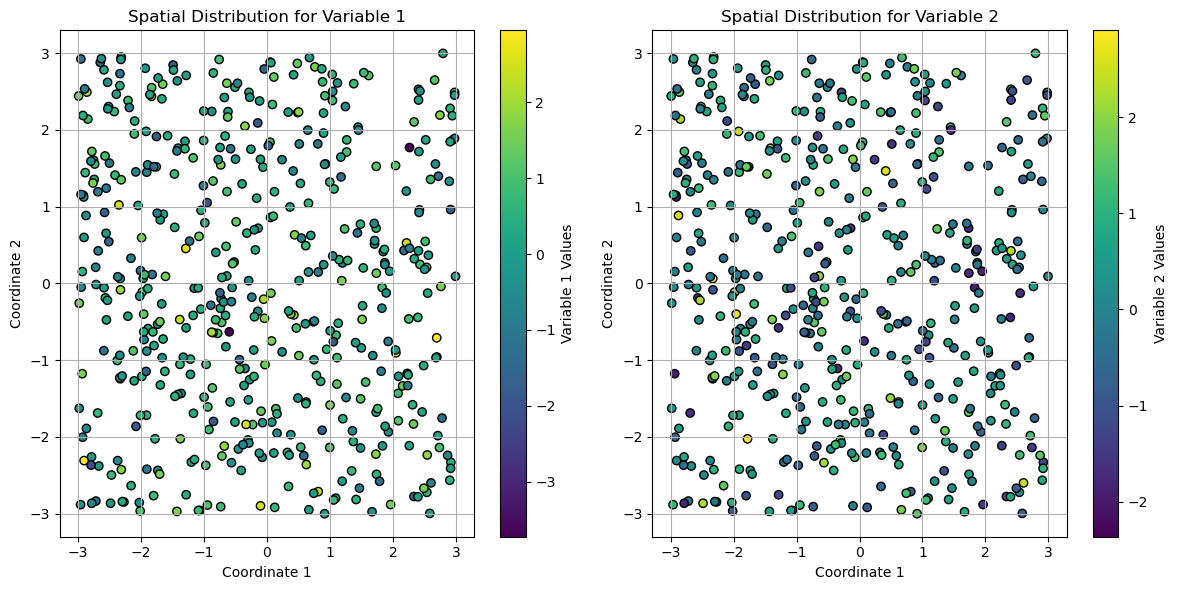

In [3]:
# Simulate bivariate data
data_size = 500
X = np.random.uniform(-3., 3., (data_size, 2))
# Generate covariance matrix
mean = np.zeros(2 * len(X))
initial_params = [1.5, 1, 1, 0.5, 0.2,1,  1, 0.6, 0.5]
K = generate_bivariate_matern_covariance(X, initial_params)

# # Check if matrix is positive definite
# print("Is the covariance matrix positive definite?", is_positive_definite(K))

data = multivariate_normal.rvs(mean=mean, cov=K).reshape(-1, 2)
print("working with simulated data set")

# Generate and Flatten the data for optimization
y_data = data.reshape(-1)

# Plot the data and continuous fields
plot_data_and_fields(X, data)

In [4]:
y_data_first = y_data[:data_size]
y_data_second = y_data[data_size:]
# len(y_data_first)
# len(y_data_second)

## Let me estimate the first variable marginally. 

In [5]:
def optimise_marginal (y_data = y_data_first):
    # Bounds and options for the optimizer
    bounds = [
        (np.finfo(np.float32).eps, 10.0),  # nu: smoothness parameter for the variable
        (np.finfo(np.float32).eps, 10.0),  # a: length scale for the variable
        (np.finfo(np.float32).eps, 10.0),      # sigma: standard deviation for the variable
    ]
    options = {'maxiter': 10000, 'gtol': 1e-15}
    initial_params_marginal = [1.0, 0.01, 1.0]
    
    # Minimize the negative log-likelihood
    result = minimize(negative_log_likelihood_marginal, initial_params_marginal, args=(X, y_data), bounds=bounds, options=options)
    # Output the optimal parameters with descriptions
    # print("Optimal marginal parameters of the variable:")
    # print(result.x)
    # print("Success:", result.success)
    # print("Message:", result.message)
    # print("Number of iterations:", result.nit)
    return result
    
result_first = optimise_marginal(y_data_first)    
print(result_first)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -229.37828951471818
        x: [ 9.455e-01  1.548e+00  1.006e+00]
      nit: 19
      jac: [ 4.309e-03  3.888e-03 -2.478e-03]
     nfev: 108
     njev: 27
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


In [6]:
result_second = optimise_marginal(y_data_second)
print(result_second)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 613.1992295547182
        x: [ 1.602e-01  5.872e-01  9.520e-01]
      nit: 24
      jac: [-1.023e-04  0.000e+00  5.684e-05]
     nfev: 144
     njev: 36
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


## Before we do anything particularly crazy, let me check that, after 500 simulations, the estimates do cover the ground truth. 

In [7]:
def simulate_data(data_size = 500):
    X = np.random.uniform(-3., 3., (data_size, 2))
    # Generate covariance matrix
    mean = np.zeros(2 * len(X))
    initial_params = [1.5, 1, 1, 0.5, 0.2, 1,  1, 0.6, 0.5]
    K = generate_bivariate_matern_covariance(X, initial_params)    
    data = multivariate_normal.rvs(mean=mean, cov=K).reshape(-1, 2)
    
    # Generate and Flatten the data for optimization
    y_data = data.reshape(-1)
    y_data_first = y_data[:data_size]
    y_data_second = y_data[data_size:]
    return (X, y_data, y_data_first, y_data_second)

In [8]:
# This the remaining three parameters used in Genton
def tau_1(nu12, nu1, nu2, d=2):
    numerator = B(nu12, d/2)**2
    denominator = B((nu1 + nu2)/2, d/2)**2
    return numerator / denominator

def tau_2(a1, a2, a12, Delta_A):
    return (a1 * a2 / a12**2)**(2 * Delta_A)

def tau_3(nu1, nu2, a1, a2, a12):
    numerator = Gamma((nu1 + nu2)/2)**2 / a12**(2 * (nu1 + nu2))
    denominator = (Gamma(nu1) / a1**(2 * nu1)) * (Gamma(nu2) / a2**(2 * nu2))
    return numerator / denominator

def Genton_parametrisation(Genton_params, estimated_params):
    nu1, a1, sigma_1, nu2, a2, sigma_2 = estimated_params
    Delta_A, Delta_B, rho_V= Genton_params
    
    nu12 = nu1/2+nu2/2 + Delta_A
    a12 = np.sqrt(a1**2 /2 + a2**2 /2 + Delta_B)
    tau1 = tau_1(nu12, nu1, nu2, d=2)
    tau2 = tau_2(a1, a2, a12, Delta_A)
    tau3 = tau_3(nu1, nu2, a1, a2, a12)
    sigma_12 = np.sqrt(rho_V*rho_V * sigma_1 * sigma_2* tau1 * tau2 * tau3)
    return (nu1, a1, sigma_1, nu2, a2, sigma_2, nu12, a12, sigma_12)

In [9]:
# X, y_data, y_data_first, y_data_second = simulate_data(data_size = 1000)
# result_first = optimise_marginal(y_data_first)
# result_second = optimise_marginal(y_data_second)
# nu1_estimated, a1_estimated, sigma_1_estimated = result_first.x
# nu2_estimated, a2_estimated, sigma_2_estimated = result_second.x

## Having done the above sanity check, I can proceed to look at the particular parametrisation used in the paper. 



## Let's keep going.  Upon specifying the three parameters $(\Delta_A, \Delta_b, \rho_V)$, we can do an optimisation that deals only with three parameters.  The Genton_params are a triplet with which we can obtain the full params.  
## The objective function depends on those three parameters only.  

In [10]:
# Negative log-likelihood function for optimization
def negative_log_likelihood_Genton(Genton_params, X, y, estimated_params):
    K = generate_bivariate_matern_covariance(X, Genton_parametrisation(Genton_params, estimated_params))
    if not is_positive_definite(K):
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf
    
    try:
        L = cho_factor(K)
        alpha = cho_solve(L, y)
        log_likelihood = -0.5 * np.dot(y.T, alpha)
        log_likelihood -= np.sum(np.log(np.diag(L[0])))
        log_likelihood -= K.shape[0] / 2 * np.log(2 * np.pi)
        return -log_likelihood
    except np.linalg.LinAlgError:
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf

def optimise_Genton (y_data = y_data, estimated_params = [1,1,1,1,1,1]):
    # Bounds and options for the optimizer
    bounds = [
        (np.finfo(np.float32).eps, 10.0),  # Delta_A: 
        (np.finfo(np.float32).eps, 10.0),  # Delta_B: 
        (np.finfo(np.float32).eps, 1.0-np.finfo(np.float32).eps), # rho_V: 
    ]
    options = {'maxiter': 10000, 'gtol': 1e-15}
    initial_params_Genton = [1.0, 0.01, 1.0]
    
    # Minimize the negative log-likelihood
    result = minimize(negative_log_likelihood_Genton, initial_params_Genton, args=(X, y_data, estimated_params), bounds=bounds, options=options)
    return result
    
# Initialize lists to store the results
nu1_estimates = []
a1_estimates = []
sigma_1_estimates = []
nu2_estimates = []
a2_estimates = []
sigma_2_estimates = []
nu12_estimates = []
a12_estimates = []
sigma_12_estimates = []


counter = 500  # Number of iterations
data_size = 750
for _ in range(counter):
    try:
        X, y_data, y_data_first, y_data_second = simulate_data(data_size=data_size)
        
        result_first = optimise_marginal(y_data_first)
        result_second = optimise_marginal(y_data_second)
        nu1_estimated, a1_estimated, sigma_1_estimated = result_first.x
        nu2_estimated, a2_estimated, sigma_2_estimated = result_second.x
        
        estimated_params = [nu1_estimated, a1_estimated, sigma_1_estimated, nu2_estimated, a2_estimated, sigma_2_estimated]
        
        result_Genton = optimise_Genton(y_data, estimated_params)
        nu1_estimated, a1_estimated, sigma_1_estimated, nu2_estimated, a2_estimated, sigma_2_estimated, nu12_estimated, a12_estimated, sigma_12_estimated = Genton_parametrisation(result_Genton.x, estimated_params)
    
        nu1_estimates.append(nu1_estimated)
        a1_estimates.append(a1_estimated)
        sigma_1_estimates.append(sigma_1_estimated)
        nu2_estimates.append(nu2_estimated)
        a2_estimates.append(a2_estimated)
        sigma_2_estimates.append(sigma_2_estimated)
        nu12_estimates.append(nu12_estimated)
        a12_estimates.append(a12_estimated)
        sigma_12_estimates.append(sigma_12_estimated)
        
    except Exception as e:
        # Handle the exception
        print(f"An error occurred: {e}")
        # Optionally, you can log the error, skip to the next iteration, etc.
        continue  # This will continue to the next iteration of the loop

/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


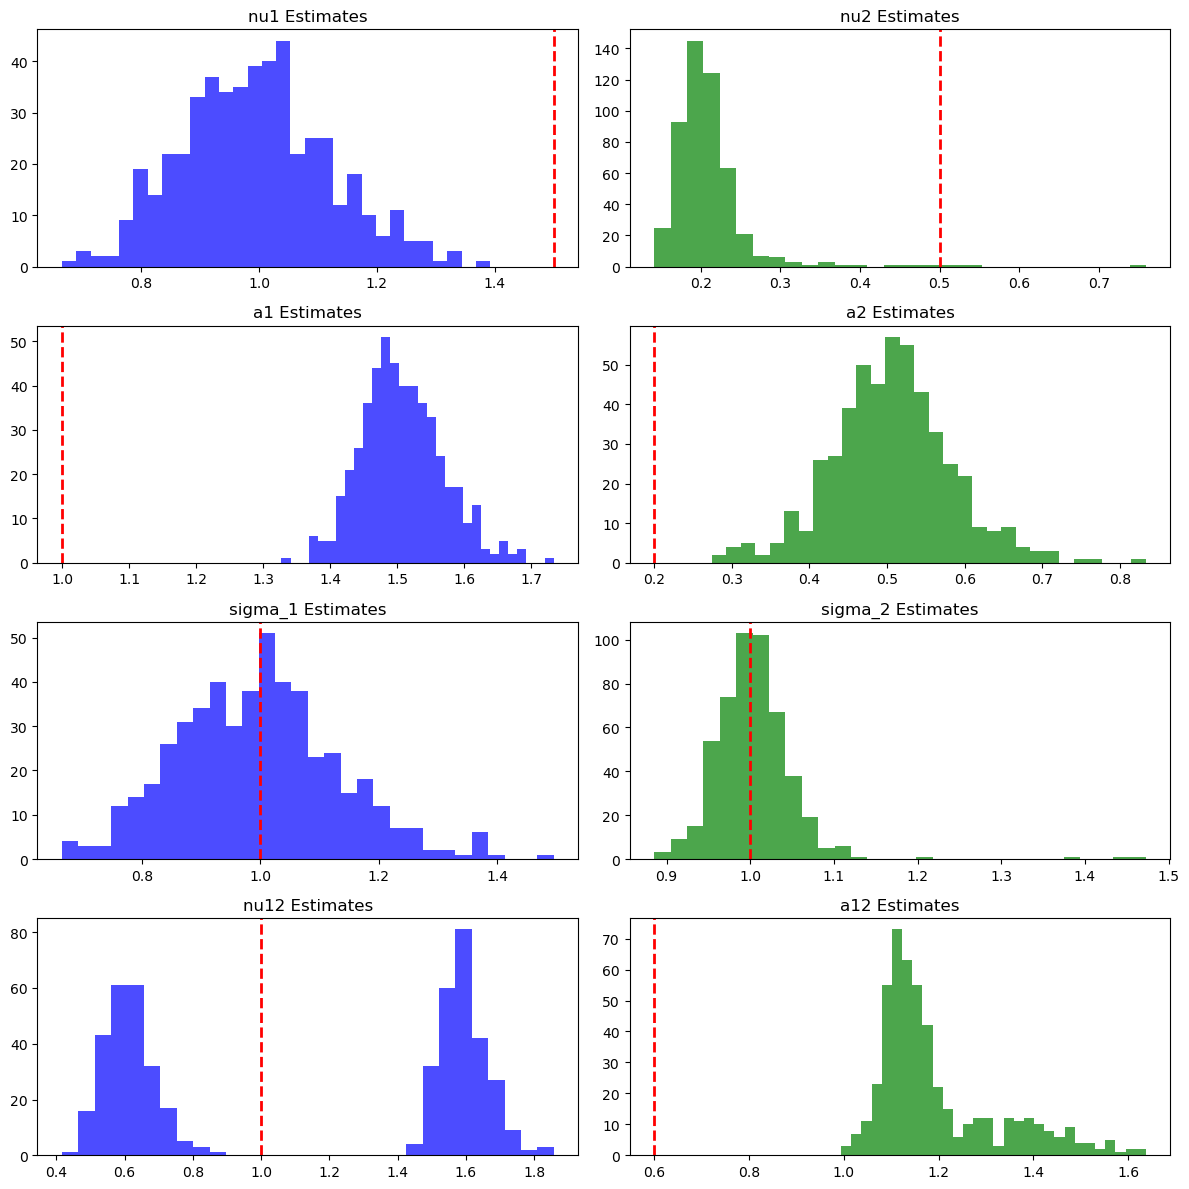

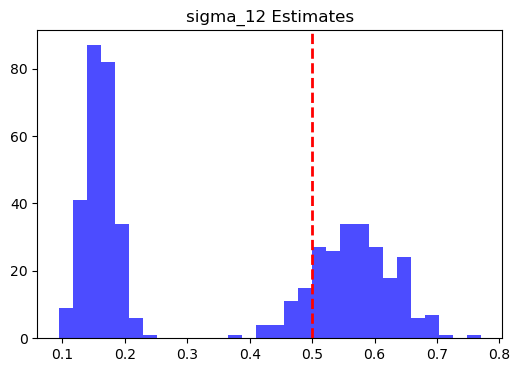

In [11]:
# Ground truth values
nu1_truth, a1_truth, sigma_1_truth, nu2_truth, a2_truth, sigma_2_truth, nu12_truth, a12_truth, sigma_12_truth = [1.5, 1, 1, 0.5, 0.2, 1, 1, 0.6, 0.5]

# Plotting histograms
plt.figure(figsize=(12, 12))

plt.subplot(4, 2, 1)
plt.hist(nu1_estimates, bins=30, color='blue', alpha=0.7)
plt.axvline(nu1_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('nu1 Estimates')

plt.subplot(4, 2, 2)
plt.hist(nu2_estimates, bins=30, color='green', alpha=0.7)
plt.axvline(nu2_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('nu2 Estimates')

plt.subplot(4, 2, 3)
plt.hist(a1_estimates, bins=30, color='blue', alpha=0.7)
plt.axvline(a1_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('a1 Estimates')

plt.subplot(4, 2, 4)
plt.hist(a2_estimates, bins=30, color='green', alpha=0.7)
plt.axvline(a2_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('a2 Estimates')

plt.subplot(4, 2, 5)
plt.hist(sigma_1_estimates, bins=30, color='blue', alpha=0.7)
plt.axvline(sigma_1_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('sigma_1 Estimates')

plt.subplot(4, 2, 6)
plt.hist(sigma_2_estimates, bins=30, color='green', alpha=0.7)
plt.axvline(sigma_2_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('sigma_2 Estimates')

plt.subplot(4, 2, 7)
plt.hist(nu12_estimates, bins=30, color='blue', alpha=0.7)
plt.axvline(nu12_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('nu12 Estimates')

plt.subplot(4, 2, 8)
plt.hist(a12_estimates, bins=30, color='green', alpha=0.7)
plt.axvline(a12_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('a12 Estimates')

plt.tight_layout()
plt.show()

# Plotting sigma_12 in a new figure to avoid overlapping too much
plt.figure(figsize=(6, 4))
plt.hist(sigma_12_estimates, bins=30, color='blue', alpha=0.7)
plt.axvline(sigma_12_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('sigma_12 Estimates')
plt.show()